# **Rayan International AI Contest**

<font color='black' style='font-family: "Times New Roman", Times, serif; font-size: 24px;'><strong>Machine Learning & Deep Learning Course </strong></font>

<font color='black' style='font-family: "Times New Roman", Times, serif; font-size: 20px;'><em>**Homework 1** || **Title**: Introduction to Machine Learning</em></font>


# Credit Card Fraud Detection

This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.



## Importing Libraries


In [ ]:
!pip install scikit-plot

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
#import scikitplot as skplt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
import cv2
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVC

## Load Dataset

In [ ]:
# Dataset Link: https://www.kaggle.com/datasets/mojtabanafez/rayan-homework1/data
!kaggle datasets download -d mojtabanafez/rayan-homework1

Dataset URL: https://www.kaggle.com/datasets/mojtabanafez/rayan-homework1
License(s): apache-2.0
rayan-homework1.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip ./rayan-homework1.zip

Archive:  ./rayan-homework1.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
df = pd.read_csv('./creditcard.csv')
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Separate features and target variable
X = df.drop('Class', axis=1)
y = df['Class']
X.shape, y.shape

((284807, 30), (284807,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis (EDA)



**Student Task:**
1. Check Summary Statistics for the Dataset
2. Visualize Distribution of Classes
3. Check Correlation Matrix
4. Plot the Distribution of Some Selected Features
5. Additional Analysis (Choose at Least 5)
    * Example: Data Visualization (After Dimension Reduction), Outlier Detection, Feature Engineering, Insightful Plots, ...

In [ ]:
# ### 2.1 Summary Statistics
# Display summary statistics for the dataset
summary_stats = df.describe()
print(summary_stats)
mean_values = df.mean()
print("Mean values:\n", mean_values)
median_values = df.median()
print("Median values:\n", median_values)
mode_values = df.mode().iloc[0]
print("Mode values:\n", mode_values)

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

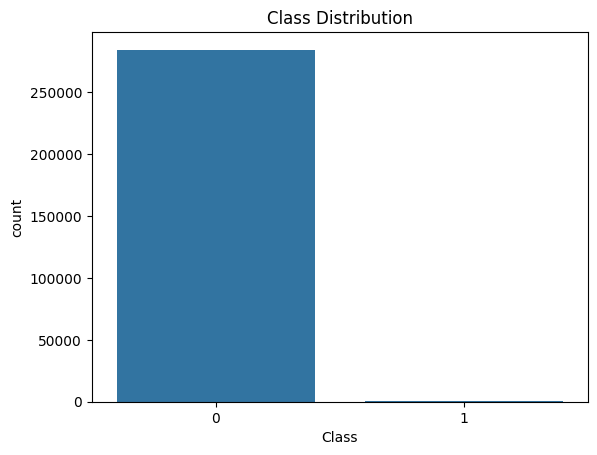

In [ ]:
# ### 2.2 Class Distribution
# Visualize the class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()


In [ ]:
# Display the class distribution in percentages
# Calculate percentage distribution
class_distribution = df['Class'].value_counts(normalize=True) * 100
# Format the output
class_distribution = class_distribution.rename('proportion')
print("Class Distribution:\n", class_distribution)

Class Distribution:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


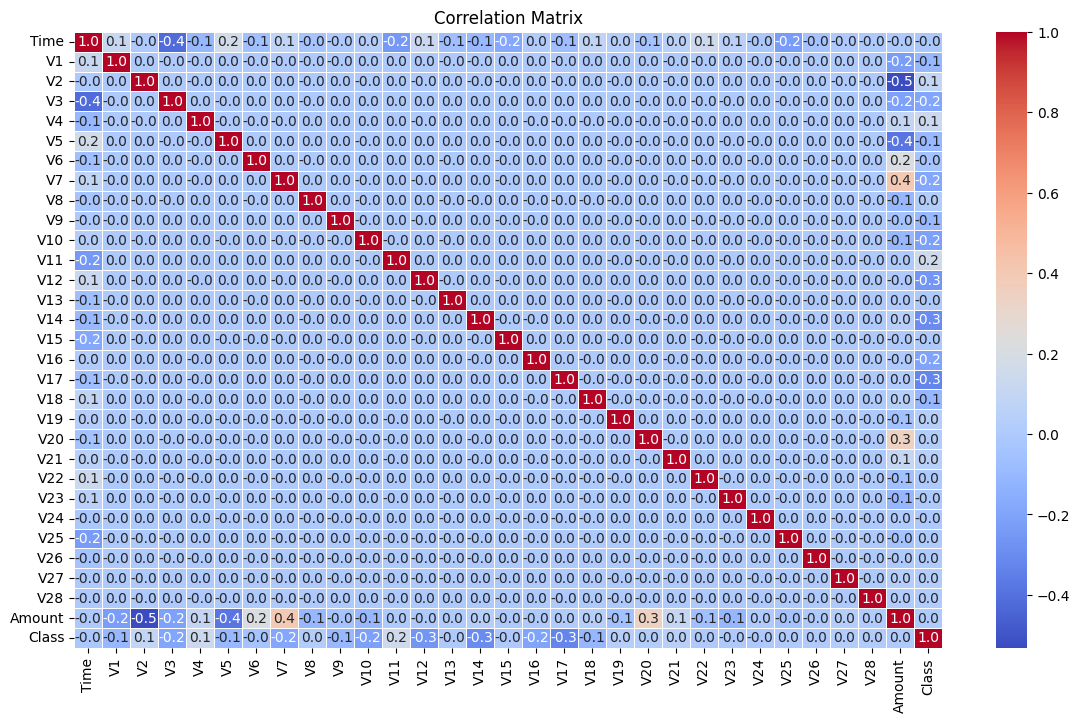

In [ ]:
# ### 2.3 Correlation Matrix
# Compute the correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt='.1f', linewidths=0.5 )
plt.title('Correlation Matrix')
plt.show()

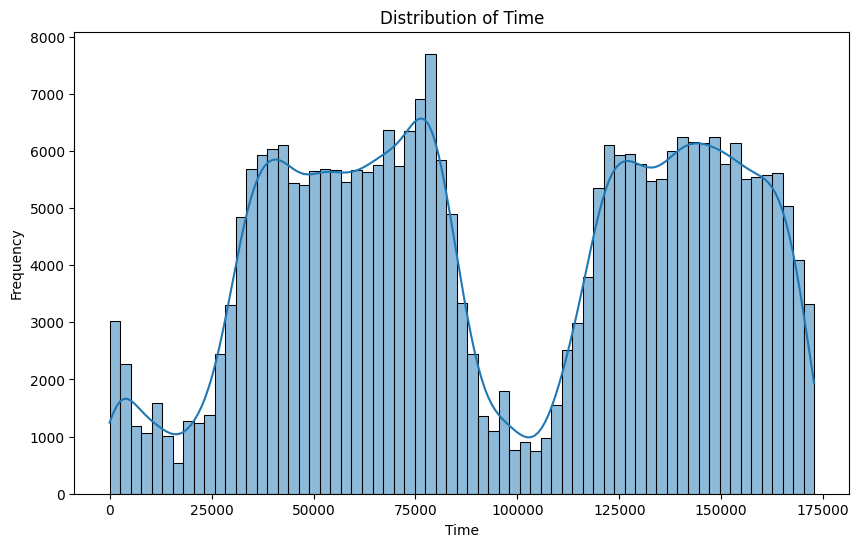

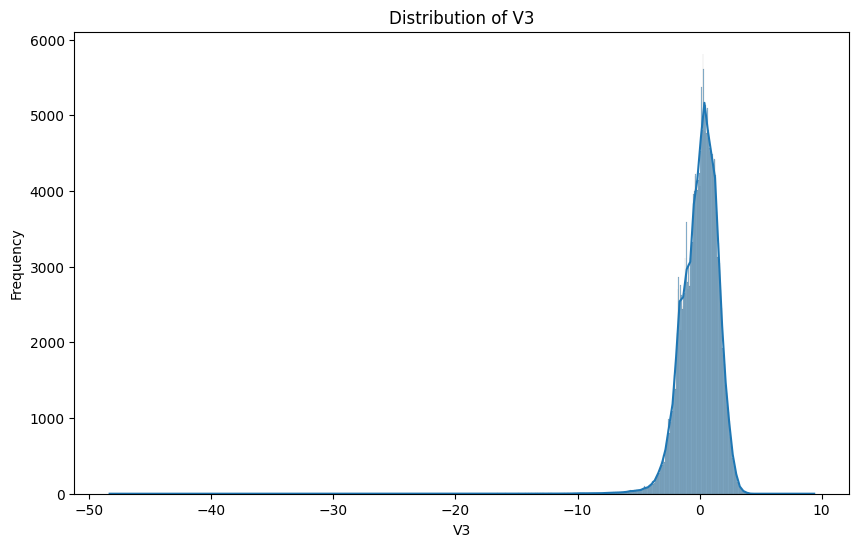

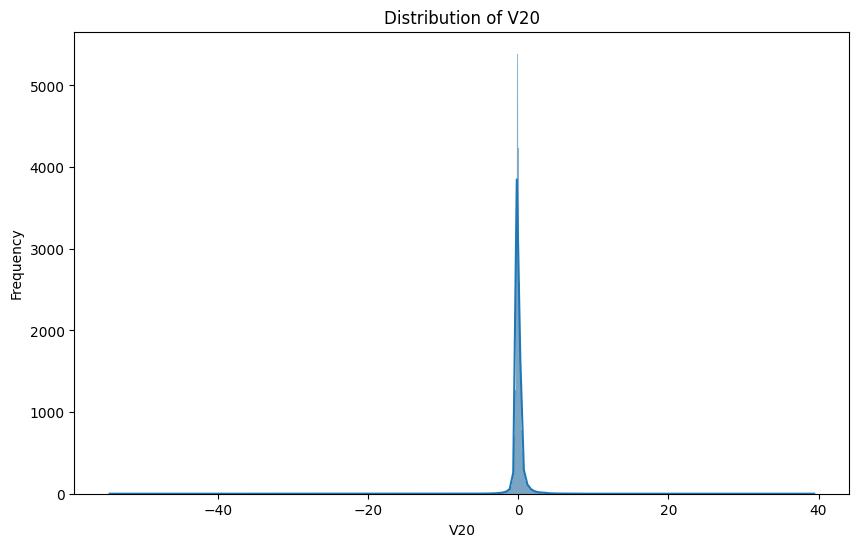

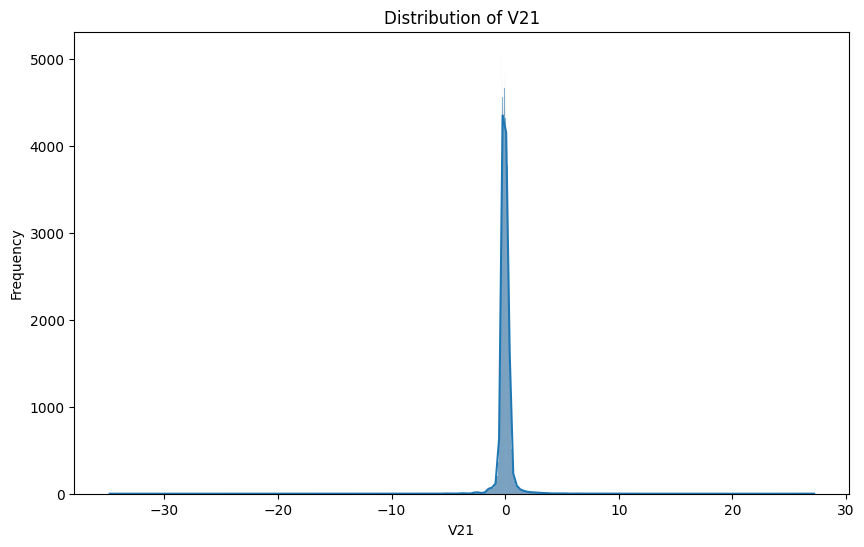

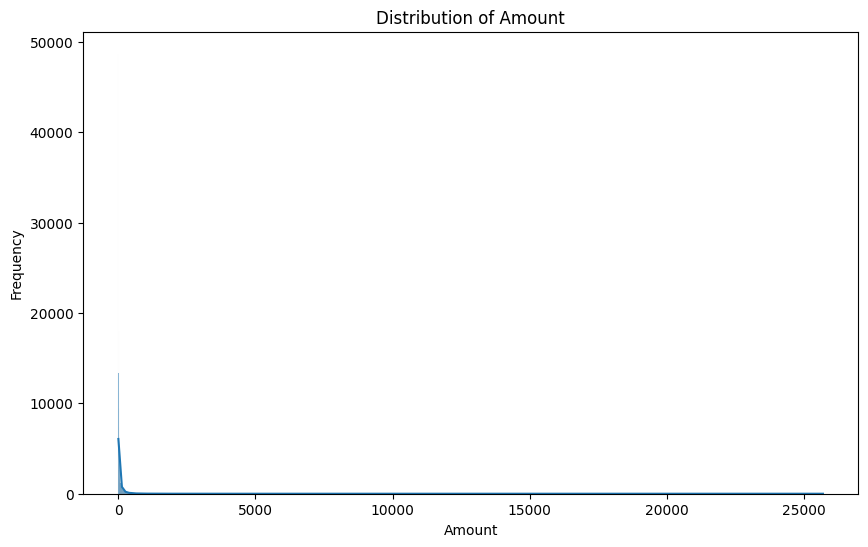

In [ ]:
# ### 2.4 Feature Distributions
# Plot the distribution of a few selected features
selected_features = ['Time', 'V3', 'V20', 'V21', 'Amount']
for feature in selected_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()



Missing Data:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


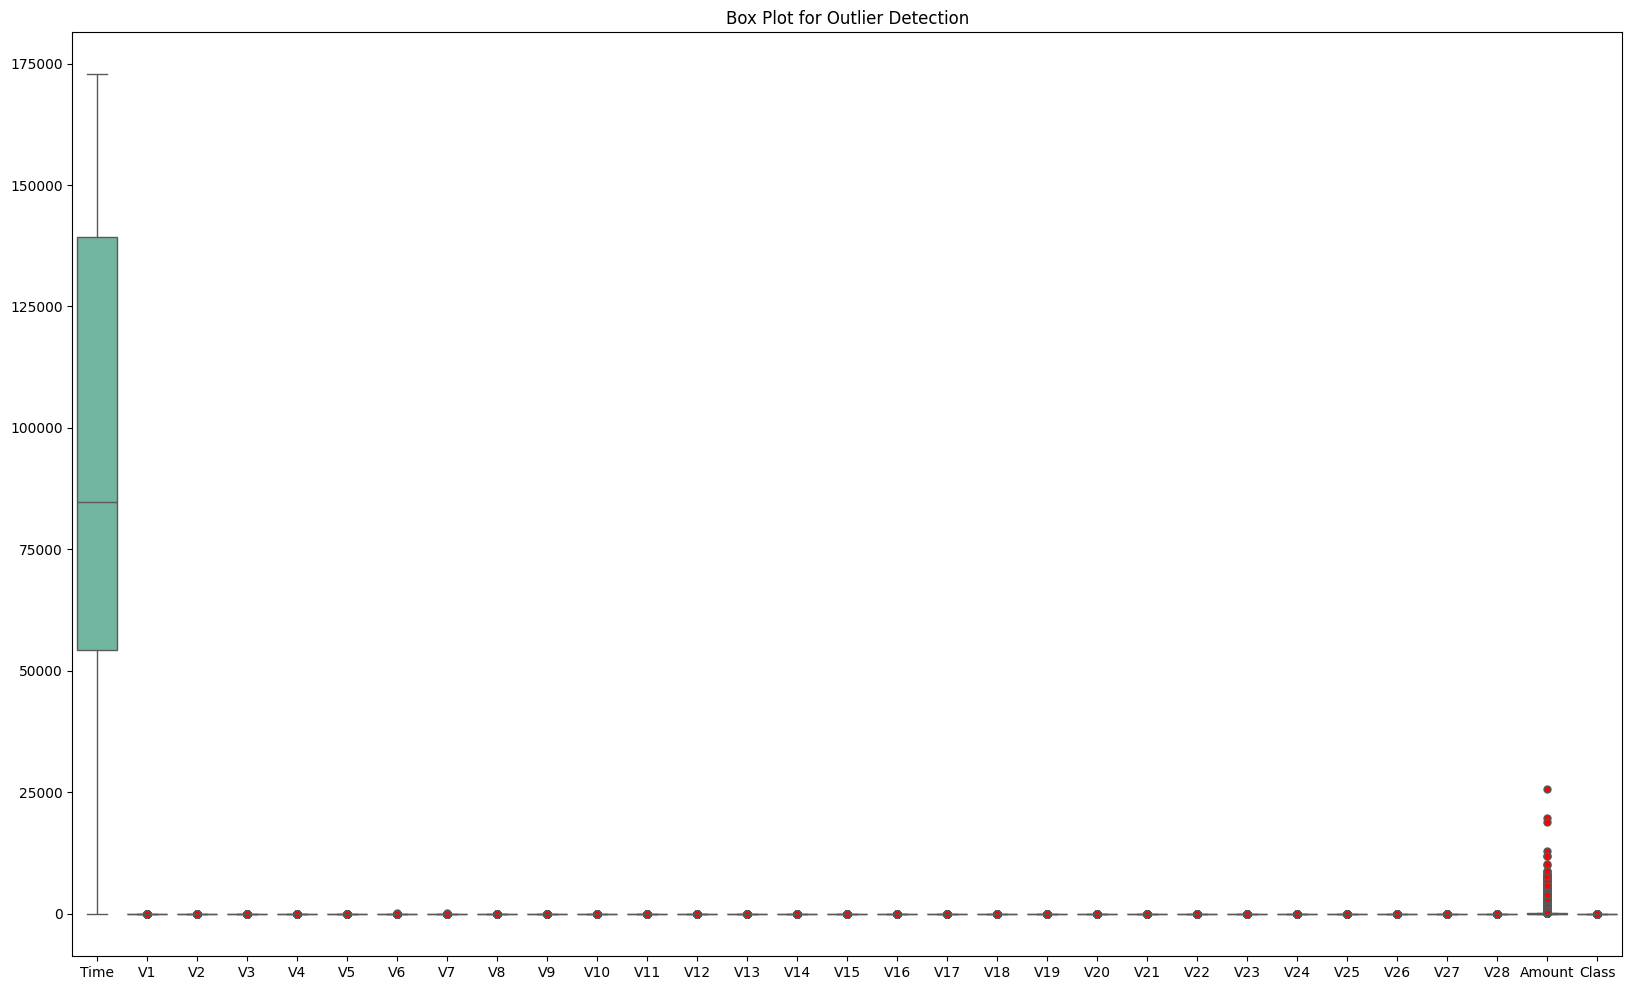

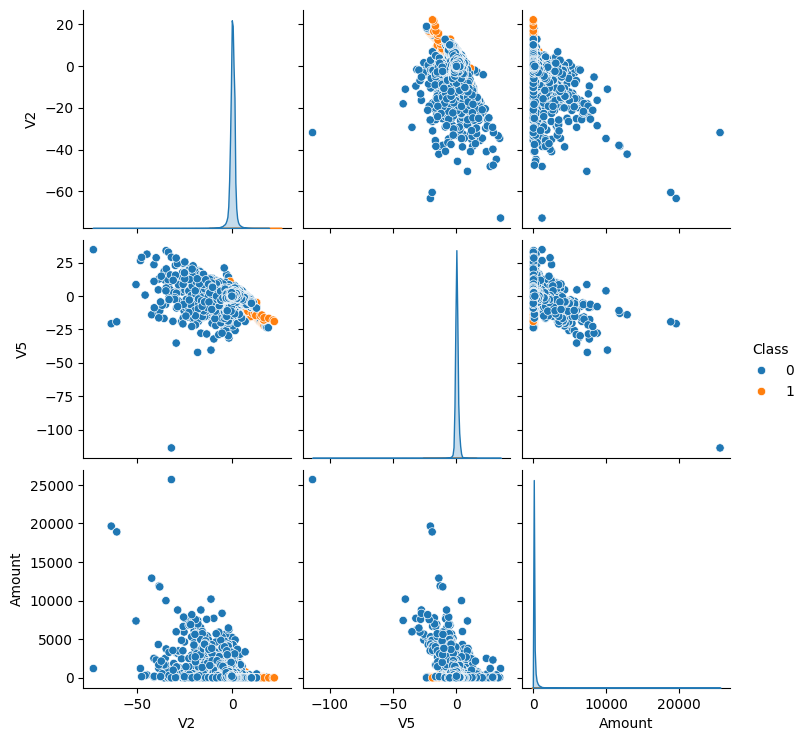

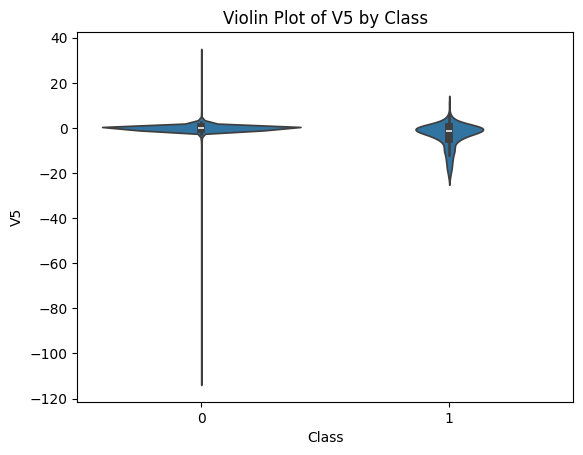

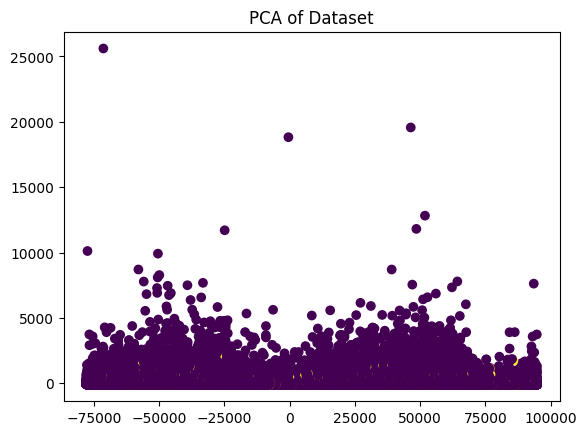

In [ ]:
##########################################################
### You can add more creative analysis to learn more...###
# Create a copy of the primary DataFrame
df2 = df.copy()
# Missing Data Analysis
missing_data = df2.isnull().sum()
print("Missing Data:\n", missing_data)
# Outlier Detection
plt.figure(figsize=(20, 12))
sns.boxplot(data=df2, palette="Set2",fliersize=5, flierprops={'markerfacecolor':'r', 'marker':'o'} )
plt.title('Box Plot for Outlier Detection')
plt.show()
#Feature Engineering and feature transformation
df2['V1*V2'] = df2['V1'] * df2['V2']
# Plot Pair Plots & violin plot
# Plot the pair plot
sns.pairplot(df2, vars=['V2','V5','Amount'] , hue='Class')
plt.show()
# Plot the violin plot
sns.violinplot(x='Class', y='V5', data=df2)
plt.title('Violin Plot of V5 by Class')
plt.show()
# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df)
# Ensure 'Class' column has no NaNs
df2['Class'] = df2['Class'].fillna(df2['Class'].mode()[0])
# Plot the results
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=df2['Class'])
plt.title('PCA of Dataset')
plt.show()
features = df2.drop('Class', axis=1)
labels = df2['Class']
X = features
y = labels
# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
# Fit the SVM model
model = SVC(kernel='linear')
model.fit(X_imputed, y)
# Check if the model found a separating hyperplane
if model.score(X_imputed, y) == 1.0:
    print("Data is linearly separable")
else:
    print("Data is not linearly separable")

## Student Question

1. Describe at least two major challenges in the dataset based on your EDA findings.
2. Analyze the correlation matrix of the features.
3. Is your data linearly separable? Please provide a rationale.

  **Student Answer:**  
  1.
  Challenge1: It was mentioned before that the data is unbalanced.
  Challenge2: existance of outlier in dataset espicially in Amount column.
  Challenge3: dataset needs to Normalization.
  2. The correlation matrix shows that the time feature has a high correlation with all the other features, also there are significantly positive and negative correlations between some features eg. V2 and V5 show a notably negative correlation with Amount while  V7 and V2o show a notably positive correlation with Amount.
  3. According to the fitted SVM model(kernel=linear), data isn't linearly separable. Also, the pair plotting of features shows data isn't linearly separable.

## Data Preprocessing

Based on the challenges you've identified, recommend preprocessing methods to use during training to enhance model performance.

Some popular preprocessing techniques you can search about and learn include:

* Data Cleaning (Outlier Detection and Treatment, Handling Missing Values, ...)
* Data Transformation (Normalization, Standardization, ...)
* Feature Engineering (Feature Creation, Feature Selection, ...)
* Data Reduction (Dimensionality Reduction, Sampling, ...)
* Resampling Techniques (Oversampling or Undersampling)
* Handling Imbalanced Data
* ...


In [ ]:
# Create a copy of the primary DataFrame
df3 = df.copy()
# check for missing value
missed_value = df3.isnull().sum()
print(missed_value)
features = df2.drop('Class', axis=1)
labels = df2['Class']
X = features
y = labels

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
# Undersampling data
from imblearn.under_sampling import RandomUnderSampler
# Initialize RandomUnderSampler
sampler = RandomUnderSampler(random_state=42)
#fit and apply resampling
X_resample, y_resample = sampler.fit_resample(X, y)
# Converting the resampled data to a DataFrame
downsampled_data = pd.concat([pd.DataFrame(X_resample, columns=X.columns), pd.DataFrame(y_resample, columns=['Class'])], axis=1)
downsampled_data.head()
X_train, X_test, y_train, y_test = train_test_split(X_resample, y_resample, test_size=0.3, random_state=42)

In [ ]:
# normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print(X_train_scaled.head())


       Time        V1        V2        V3        V4        V5        V6  \
0 -0.820052  0.680456 -0.652247  0.285877 -1.255494  0.823710  2.056743   
1 -1.607767 -0.426944  0.324268 -0.320192  1.102660 -0.135797 -0.468920   
2  0.113427 -4.301897  3.940539 -4.246246  2.007632 -3.834091 -0.295591   
3 -1.701603  0.545512  0.124389 -0.277323  0.518645 -0.027368 -0.585579   
4 -1.763720  0.037676  0.178370  0.682645 -0.083584  0.276332  1.086104   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  0.374887  0.070711  0.008008  ... -0.068165  0.152684 -0.184653  1.955468   
1 -0.273692  0.136282 -0.000662  ...  0.106955  0.221030  0.547112 -0.355509   
2 -4.722303 -2.316729 -3.432899  ... -3.141921  2.908210  0.780675  0.531017   
3 -0.187279  0.165534  0.344816  ...  0.085777  0.099121  0.522858 -0.583131   
4  0.320285 -0.552890  0.862821  ...  0.801614 -1.630894  0.305870 -1.005980   

        V25       V26       V27       V28    Amount     V1*V2  
0  1

## Training

1. Train your model on the preprocessed and unpreprocessed training data.
2. Report followning evaluaiton metrics: Accuracy, Accuracy, Recall, Precision, Confusion Matrix
3. Evaluation your best model using K-Fold Cross Validation
3. Crucial Step: Enhance Your Model's Performance

**Please note:** The results in our cell output represent the minimum achievable. Try to surpass these results and analyze multiple ideas and attempts.








### Logistic Regression

Mean Squared Error: 0.0777027027027027
Accuracy: 0.9222972972972973
Recall: 0.8972602739726028
Precision: 0.9424460431654677
Confusion Matrix:
[[142   8]
 [ 15 131]]


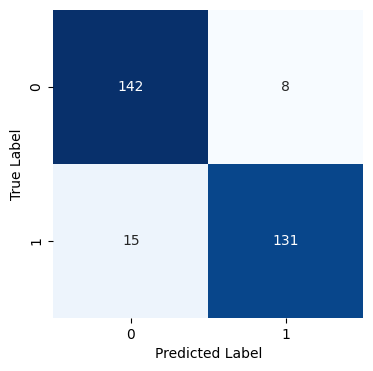

Mean Squared Error: 0.07432432432432433
Accuracy: 0.9256756756756757
Recall: 0.8835616438356164
Precision: 0.9626865671641791
Confusion Matrix:
[[145   5]
 [ 17 129]]


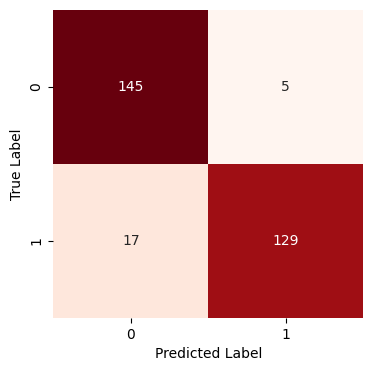

In [ ]:
# Training model on the unpreprocessed training data
# Fit the Linear Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Predict and evaluate
y_pred = lr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
# Report the metrics
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print('Confusion Matrix:')
print(conf_matrix)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
# Training model on the preprocessed training data
# Fit the Linear Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
# Predict and evaluate
y_pred = lr_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
# Report the metrics
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'Precision: {precision}')
print('Confusion Matrix:')
print(conf_matrix)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False,
                xticklabels=lr_model.classes_, yticklabels=lr_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(lr_model, X_train_scaled, y_train, cv=5, scoring=scoring)

print("result for cross validation:")
for metric in scoring:
    print(f"Mean {metric}: {cv_results['test_' + metric].mean():.4f} (Std: {cv_results['test_' + metric].std():.4f})")

result for cross validation:
Mean accuracy: 0.9419 (Std: 0.0120)
Mean precision: 0.9785 (Std: 0.0122)
Mean recall: 0.9048 (Std: 0.0306)
Mean f1: 0.9397 (Std: 0.0135)


### SVM

* [SVM practical example](https://www.analyticsvidhya.com/blog/2021/10/support-vector-machinessvm-a-complete-guide-for-beginners/)

Unprocessed Data:
Accuracy: 0.5878378378378378
Recall: 0.5892237442922375
Precision: 0.5930298990668444
Confusion Matrix:
[[ 73  77]
 [ 45 101]]


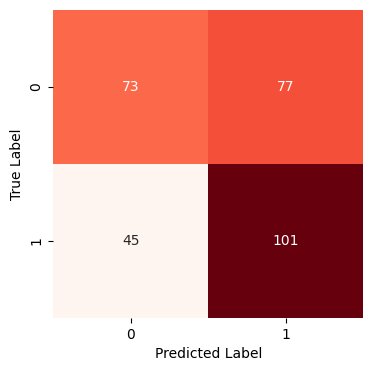


Preprocessed Data:
Accuracy: 0.9391891891891891
Recall: 0.9386301369863014
Precision: 0.9425096738529575
Confusion Matrix:
[[147   3]
 [ 15 131]]


<Axes: >

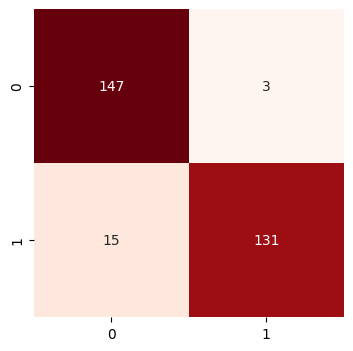

In [ ]:
# Unprocessed data
svm_unprocessed = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_unprocessed.fit(X_train, y_train)
# Preprocessed data
svm_preprocessed = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_preprocessed.fit(X_train_scaled, y_train)
# predict with Unprocessed data
y_pred_unprocessed = svm_unprocessed.predict(X_test)
# predict with Preprocessed data
y_pred_preprocessed = svm_preprocessed.predict(X_test_scaled)
# Unprocessed data
accuracy_unprocessed = accuracy_score(y_test, y_pred_unprocessed)
recall_unprocessed = recall_score(y_test, y_pred_unprocessed, average='macro')
precision_unprocessed = precision_score(y_test, y_pred_unprocessed, average='macro')
conf_matrix_unprocessed = confusion_matrix(y_test, y_pred_unprocessed)
# Preprocessed data
accuracy_preprocessed = accuracy_score(y_test, y_pred_preprocessed)
recall_preprocessed = recall_score(y_test, y_pred_preprocessed, average='macro')
precision_preprocessed = precision_score(y_test, y_pred_preprocessed, average='macro')
conf_matrix_preprocessed = confusion_matrix(y_test, y_pred_preprocessed)
print("Unprocessed Data:")
print(f"Accuracy: {accuracy_unprocessed}")
print(f"Recall: {recall_unprocessed}")
print(f"Precision: {precision_unprocessed}")
print(f"Confusion Matrix:\n{conf_matrix_unprocessed}")
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix_unprocessed, annot=True, fmt='d', cmap='Reds', cbar=False,
                xticklabels=svm_unprocessed.classes_, yticklabels=svm_unprocessed.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("\nPreprocessed Data:")
print(f"Accuracy: {accuracy_preprocessed}")
print(f"Recall: {recall_preprocessed}")
print(f"Precision: {precision_preprocessed}")
print(f"Confusion Matrix:\n{conf_matrix_preprocessed}")
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix_preprocessed, annot=True, fmt='d', cmap='Reds', cbar=False,
                xticklabels=svm_preprocessed.classes_, yticklabels=svm_preprocessed.classes_)

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(svm_preprocessed, X_train_scaled, y_train, cv=5, scoring=scoring)

print("Cross-validation results:")
for metric in scoring:
    print(f"Mean {metric}: {cv_results['test_' + metric].mean():.4f} (Std: {cv_results['test_' + metric].std():.4f})")


Cross-validation results:
Mean accuracy: 0.9317 (Std: 0.0126)
Mean precision: 0.9872 (Std: 0.0119)
Mean recall: 0.8759 (Std: 0.0260)
Mean f1: 0.9279 (Std: 0.0140)


## Student Questions

1. Compare the SVM vs Logistic Regression model? Generally which one was better?
2. Is accuracy a suitable metric for evaluating performance in this problem? Explain your rationale.
3. If achieving high recall is crucial for our problem, what recommendations do you have to enhance this metric specifically for this dataset?

  **Student Answer:**  
1. RQ1:
Accuracy: SVM has a slightly higher accuracy (0.939 vs. 0.926).
Recall: SVM also has a higher recall (0.939 vs. 0.884), meaning it is better at identifying positive cases.
Precision: Logistic Regression has a higher precision (0.963 vs. 0.943), indicating it has fewer false positives. SVM is generally better in terms of accuracy and recall, making it more reliable for identifying positive cases. Logistic Regression has a higher precision, which is beneficial to minimize false positives.
2. RQ2:
When dealing with imbalanced datasets, accuracy can be misleading. A high accuracy might just indicate the models preference for the majority class, rather than its true effectiveness across all classes. Given that our data is unbalanced, accuracy is not a reliable metric.
3. RQ3:
In fraud detection, where the classes are typically imbalanced (with fewer fraud cases compared to non-fraud cases), resampling techniques can be beneficial. Instead of relying on accuracy, its better to plot and assess models using the precision-recall curve. Additionally, employing cross-validation with recall as the scoring metric is advisable.

# Unsupervised Image Segmentation using Clustering!

Image segmentation is a crucial step in image processing and is essential for analyzing image contents. For instance, to determine if an indoor image contains a chair or a person, image segmentation can be used to isolate and examine each object individually. It typically precedes tasks like pattern recognition, feature extraction, and image compression.

Image segmentation involves classifying an image into various groups. Extensive research has been conducted in this field, particularly using clustering techniques. Among these, the K-Means clustering algorithm is one of the most widely used methods.

The process of image segmentation transforms an image into a set of pixel regions, represented by a mask or a labeled image. This segmentation allows for the targeted processing of significant image segments rather than the entire image.

In this section we want to demonstrate K-Mean able to cluster similar pixel properly. and finaly segment components of an image!

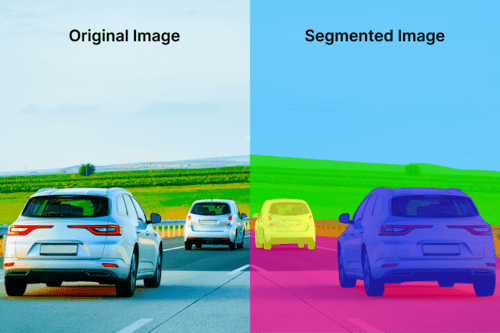

## Load Data

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Image Link (You can download and upload it): https://drive.google.com/file/d/16iMaYEGH-GgmqZfrCTw2vjYayllcgFcb/view?usp=sharing
!gdown 16iMaYEGH-GgmqZfrCTw2vjYayllcgFcb

Downloading...
From: https://drive.google.com/uc?id=16iMaYEGH-GgmqZfrCTw2vjYayllcgFcb
To: /content/elephant.jpg
100% 36.2k/36.2k [00:00<00:00, 66.7MB/s]


In [ ]:
im =  cv2.imread('./elephant.jpg') # Reads an image into BGR Format
im = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
original_shape = im.shape
print(im.shape)

(330, 500, 3)


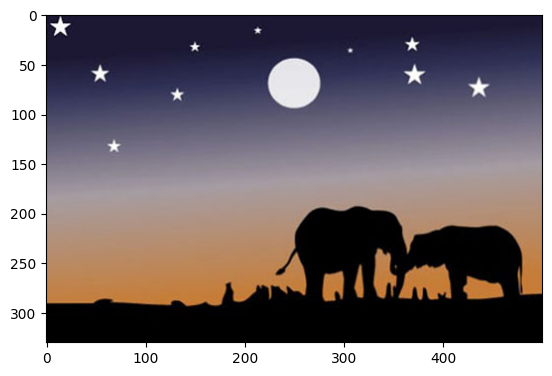

In [ ]:
plt.imshow(im) # as RGB Format
plt.show()

In [ ]:
# Flatten Each channel of the Image
all_pixels  = im.reshape((-1,3))
print(all_pixels.shape)
pixel_values = np.float32(all_pixels)

(165000, 3)


## Number of Dominant Colors in Image

The optimal number of clusters when clustering all pixels represents the predominant colors in an image.








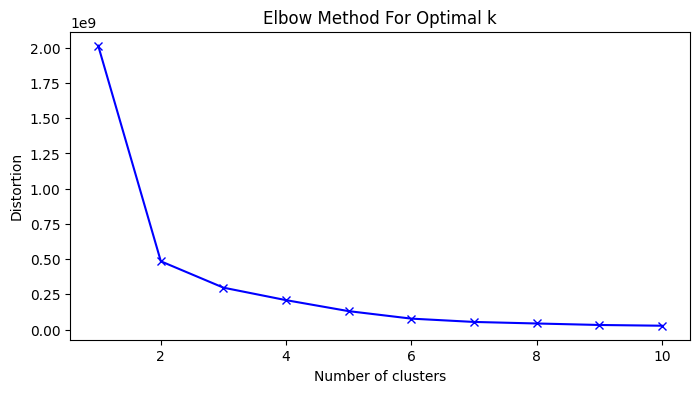

In [ ]:
# Elbow Method or # Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Determine the optimal number of clusters using the Elbow Method
distortions = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixel_values)
    distortions.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(8, 4))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method For Optimal k')
plt.show()



## Visualize Dominant Color

In [ ]:
# Now that you have the number of dominant colors (clusters),
# Apply K-Means clustering with the optimal number of clusters
optimal_k = 6  # Example value, choose based on the elbow plot
print(f'The optimal number of clusters is: {optimal_k}')

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(pixel_values)
# Get the cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_
# Create the segmented image
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(im.shape)
segmented_image = np.uint8(segmented_image)

The optimal number of clusters is: 6


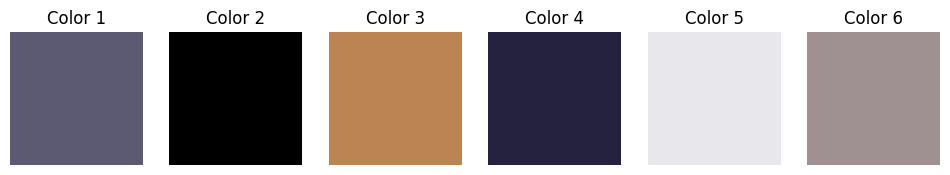

In [ ]:
#######Plot the each of dominant color as image#######
####### Dominant colors are center of cluster ########
dominant_colors = np.uint8(centers)
plt.figure(figsize=(12, 2))
for i, color in enumerate(dominant_colors):
    plt.subplot(1, optimal_k, i + 1)
    plt.imshow([[color]])
    plt.axis('off')
    plt.title(f'Color {i + 1}')
plt.show()

## Segmenting original image

In [ ]:
new_img = np.zeros((330*500,3),dtype='uint8')
print(new_img.shape)

(165000, 3)


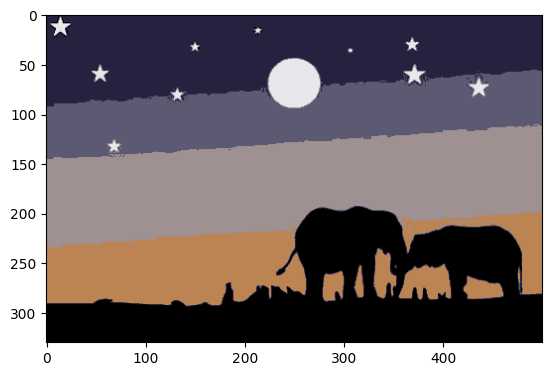

In [ ]:
colors = kmeans.cluster_centers_
lables = kmeans.labels_

# Iterate over the image
for ix in range(new_img.shape[0]):
    new_img[ix] = colors[lables[ix]]

new_img = new_img.reshape((original_shape))
plt.imshow(new_img)
plt.show()